In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from ctg_viz import CTGViz

## Preprocessing

In [2]:
df = pd.read_csv('../../datasets/CTG.csv')

In [3]:
viz = CTGViz(df)
viz.check_data_completeness_dafneelizabethzepedagonzalez()

In [36]:
df.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [5]:
varc, vard = viz.vars_classification()

In [38]:
varc

['b',
 'e',
 'LBE',
 'LB',
 'AC',
 'FM',
 'UC',
 'ASTV',
 'MSTV',
 'ALTV',
 'MLTV',
 'DL',
 'Width',
 'Min',
 'Max',
 'Nmax',
 'Mode',
 'Mean',
 'Median',
 'Variance']

In [39]:
vard

['FileName',
 'Date',
 'SegFile',
 'DS',
 'DP',
 'DR',
 'Nzeros',
 'Tendency',
 'A',
 'B',
 'C',
 'D',
 'E',
 'AD',
 'DE',
 'LD',
 'FS',
 'SUSP',
 'CLASS',
 'NSP']

In [7]:
#Imputación de datos faltantes
#Variables discretas
most_frec_imputer = SimpleImputer(strategy='most_frequent')

df[vard] = most_frec_imputer.fit_transform(df[vard])

In [8]:
#variables continuas usando KNN Imputer
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[varc])

imputer = KNNImputer(n_neighbors=5, weights='distance')

df_imputed_scaled = imputer.fit_transform(df_scaled)

df_imputed = scaler.inverse_transform(df_imputed_scaled)
df_imputed = pd.DataFrame(df_imputed, columns=varc)

df[varc] = df_imputed

In [9]:

#Validación de imputación
viz.check_data_completeness_dafneelizabethzepedagonzalez()

array([[<Axes: title={'center': 'b'}>, <Axes: title={'center': 'e'}>,
        <Axes: title={'center': 'LBE'}>, <Axes: title={'center': 'LB'}>],
       [<Axes: title={'center': 'AC'}>, <Axes: title={'center': 'FM'}>,
        <Axes: title={'center': 'UC'}>, <Axes: title={'center': 'ASTV'}>],
       [<Axes: title={'center': 'MSTV'}>,
        <Axes: title={'center': 'ALTV'}>,
        <Axes: title={'center': 'MLTV'}>, <Axes: title={'center': 'DL'}>],
       [<Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Min'}>, <Axes: title={'center': 'Max'}>,
        <Axes: title={'center': 'Nmax'}>],
       [<Axes: title={'center': 'Mode'}>,
        <Axes: title={'center': 'Mean'}>,
        <Axes: title={'center': 'Median'}>,
        <Axes: title={'center': 'Variance'}>]], dtype=object)

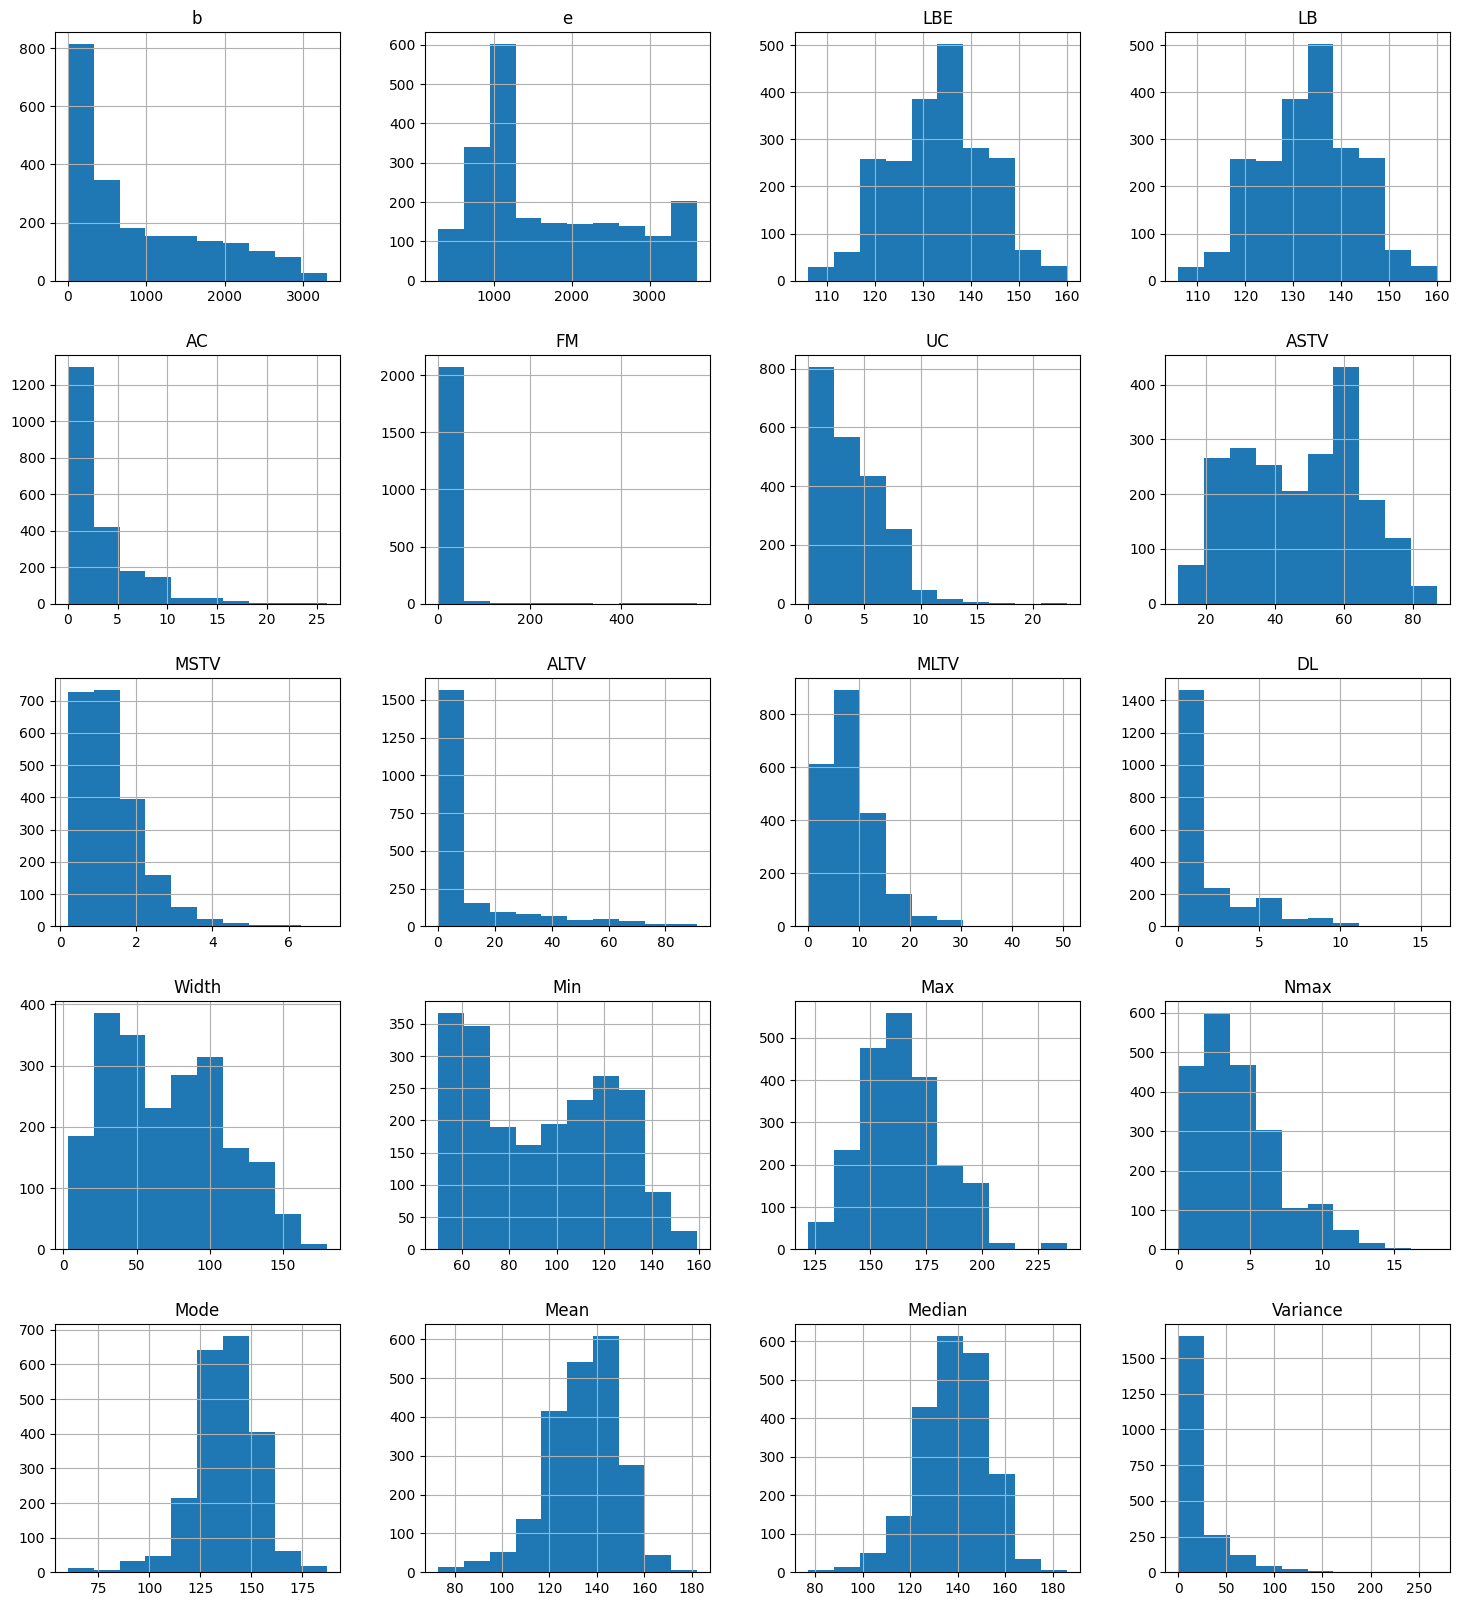

In [6]:
#Detección de {outliers
df[varc].hist(figsize=(18, 20))

array([[<Axes: title={'center': 'b'}>, <Axes: title={'center': 'e'}>,
        <Axes: title={'center': 'LBE'}>, <Axes: title={'center': 'LB'}>],
       [<Axes: title={'center': 'AC'}>, <Axes: title={'center': 'FM'}>,
        <Axes: title={'center': 'UC'}>, <Axes: title={'center': 'ASTV'}>],
       [<Axes: title={'center': 'MSTV'}>,
        <Axes: title={'center': 'ALTV'}>,
        <Axes: title={'center': 'MLTV'}>, <Axes: title={'center': 'DL'}>],
       [<Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Min'}>, <Axes: title={'center': 'Max'}>,
        <Axes: title={'center': 'Nmax'}>],
       [<Axes: title={'center': 'Mode'}>,
        <Axes: title={'center': 'Mean'}>,
        <Axes: title={'center': 'Median'}>,
        <Axes: title={'center': 'Variance'}>]], dtype=object)

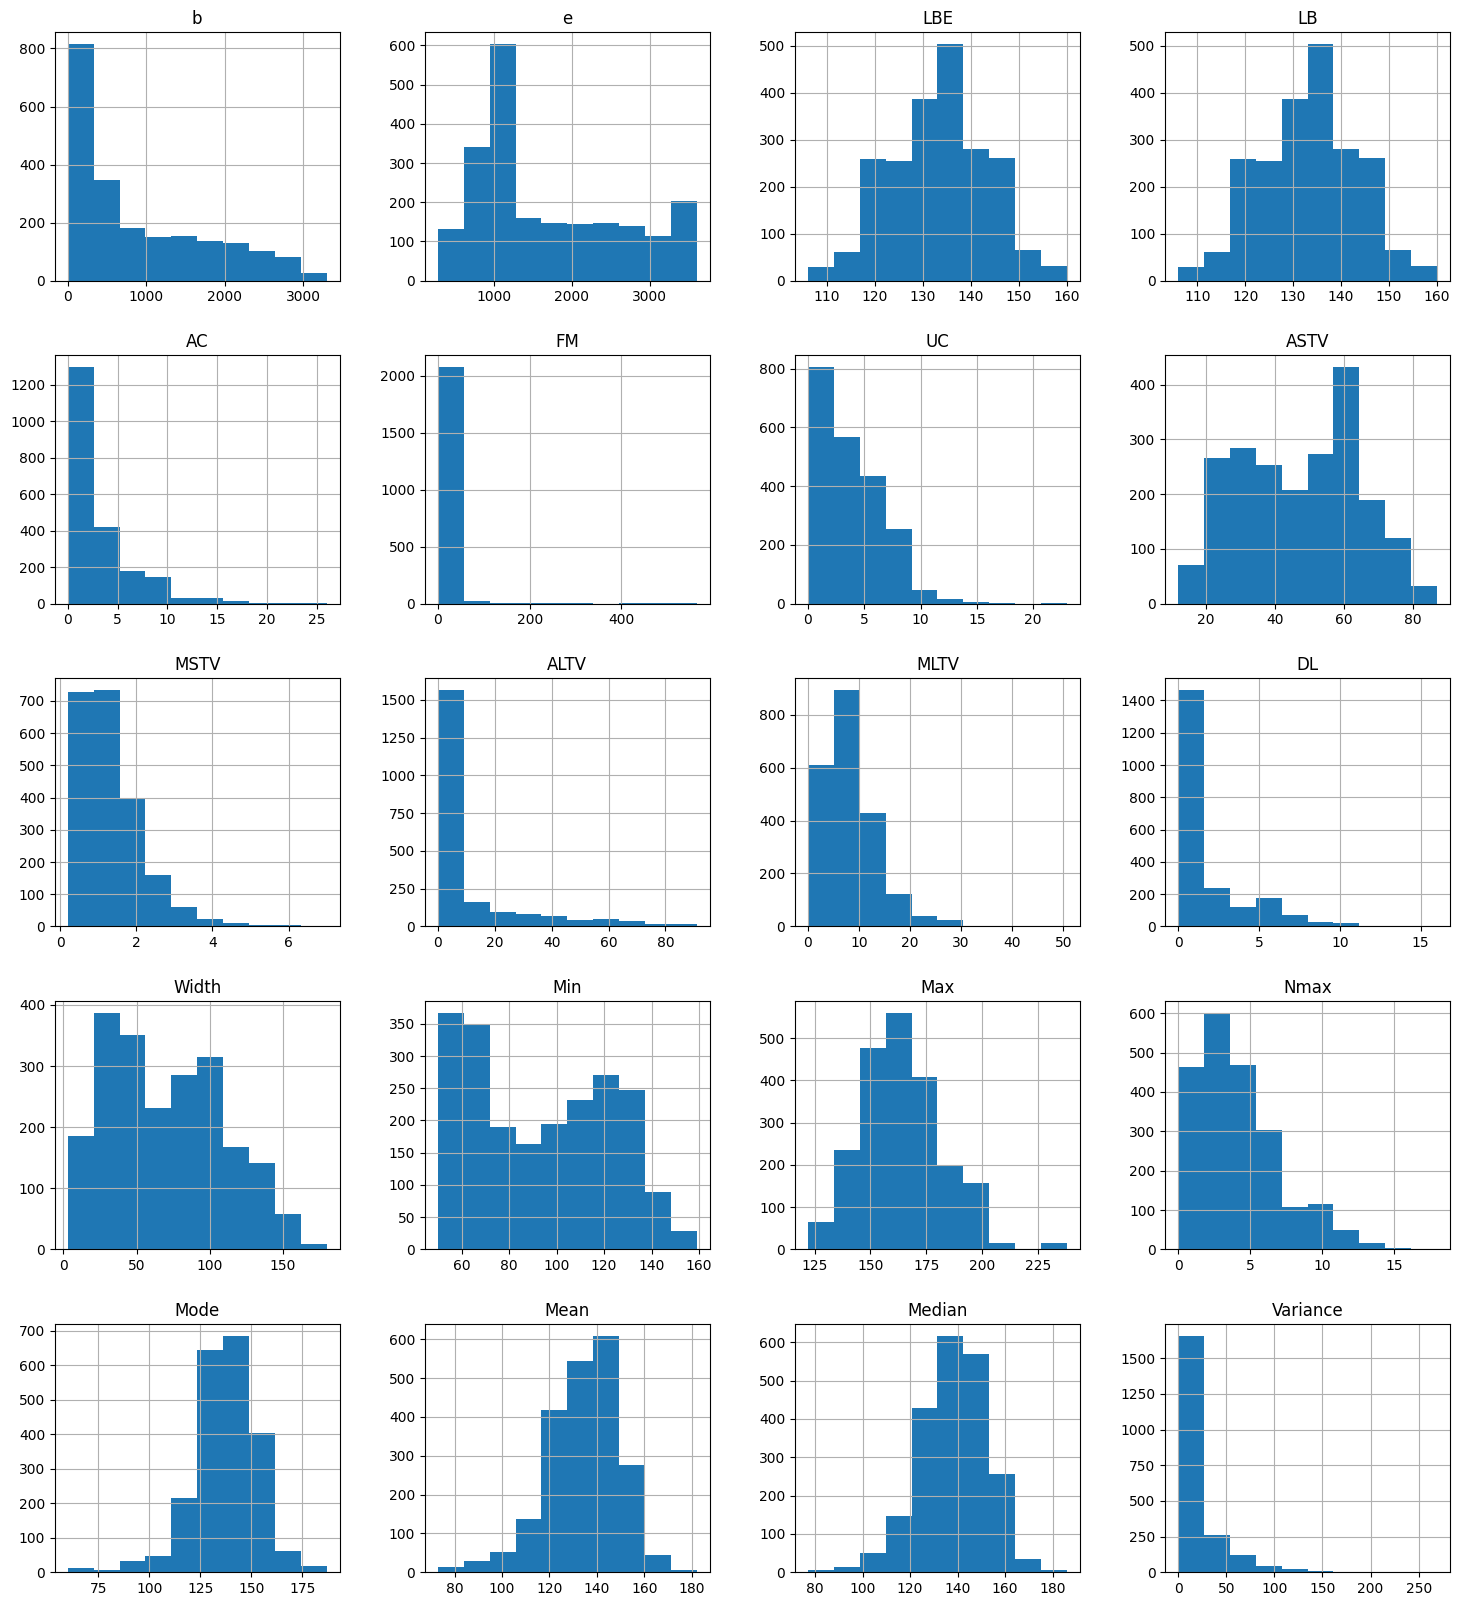

In [10]:
df[varc].hist(figsize=(18, 20))